In [1]:
import pandas as pd
import numpy as np
from coffea import util
import itertools
import os
import matplotlib.pyplot as plt
import mplhep as hep
import uproot
from hist import plot
hep.style.use("CMS")

In [2]:
IOVs = ['2016all']#, '2016', '2017', '2018']
useOldHTcut = False
useOldTaggers = False
oldTaggerstr = ''
oldHTstr = ''
if useOldHTcut:
    oldHTstr = '_oldHTcut'
if useOldTaggers:
    oldTaggerstr = '_oldBTag'

# analysis categories #

label_dict = util.load(f'../outputs/QCD_2016_15to7000.coffea')['analysisCategories']
label_to_int_dict = {label: i for i, label in label_dict.items()}

# signal_cats = [ i for label, i in label_to_int_dict.items() if '2t' in label]
# pretag_cats = [ i for label, i in label_to_int_dict.items() if 'pret' in label]
print(label_dict)

{0: 'at0bcen', 1: 'at0bfwd', 2: 'at1bcen', 3: 'at1bfwd', 4: 'at2bcen', 5: 'at2bfwd', 6: 'pret0bcen', 7: 'pret0bfwd', 8: 'pret1bcen', 9: 'pret1bfwd', 10: 'pret2bcen', 11: 'pret2bfwd', 12: '2t0bcen', 13: '2t0bfwd', 14: '2t1bcen', 15: '2t1bfwd', 16: '2t2bcen', 17: '2t2bfwd'}


In [3]:
lumi = {
    "2016APV": 19800.,
    "2016": 16120., #35920 - 19800
    "2016all": 35920,
    "2017": 41530.,
    "2018": 59740.,
    "Full": 137190.
}

t_BR = 0.6741
ttbar_BR = 0.4544 #PDG 2019
ttbar_xs1 = 831.76 * (0.09210) #pb For ttbar mass from 700 to 1000
ttbar_xs2 = 831.76 * (0.02474) #pb For ttbar mass from 1000 to Inf
toptag_sf = 1.0 #0.9
toptag_kf = 1.0 #0.7
# qcd_xs = 1373000000.0 #pb From https://cms-gen-dev.cern.ch/xsdb

In [4]:
directories = [
    'images/png/closureTestQCD/2016all',
    'images/png/closureTestQCD/2016APV',
    'images/png/closureTestQCD/2016',
    'images/png/closureTestQCD/2017',
    'images/png/closureTestQCD/2018',
    'images/png/closureTestQCD/Full',
    'images/pdf/closureTestQCD/2016all',
    'images/pdf/closureTestQCD/2016APV',
    'images/pdf/closureTestQCD/2016',
    'images/pdf/closureTestQCD/2017',
    'images/pdf/closureTestQCD/2018',
    'images/pdf/closureTestQCD/Full'
]


for path in directories:
    if not os.path.exists(path):
        os.makedirs(path)

In [5]:
# tagger='DeepAK8 top tagger'
tagger='CMS top tagger v2'

coffea_dir = '../outputs/'
coffeaFiles = {
    "unweighted": {
        "2016APV": {
            "800to1000": coffea_dir+'QCD_2016APV_800to1000_noSyst'+oldHTstr+oldTaggerstr+'.coffea',
            "1000to1400": coffea_dir+'QCD_2016APV_1000to1400_noSyst'+oldHTstr+oldTaggerstr+'.coffea',
            "1400to1800": coffea_dir+'QCD_2016APV_1400to1800_noSyst'+oldHTstr+oldTaggerstr+'.coffea',
            "1800to2400": coffea_dir+'QCD_2016APV_1800to2400_noSyst'+oldHTstr+oldTaggerstr+'.coffea',
            "2400to3200": coffea_dir+'QCD_2016APV_2400to3200_noSyst'+oldHTstr+oldTaggerstr+'.coffea',
            "3200toInf": coffea_dir+'QCD_2016APV_3200toInf_noSyst'+oldHTstr+oldTaggerstr+'.coffea'
        },
        "2016": {
            "800to1000": coffea_dir+'QCD_2016_800to1000_noSyst'+oldHTstr+oldTaggerstr+'.coffea',
            "1000to1400": coffea_dir+'QCD_2016_1000to1400_noSyst'+oldHTstr+oldTaggerstr+'.coffea',
            "1400to1800": coffea_dir+'QCD_2016_1400to1800_noSyst'+oldHTstr+oldTaggerstr+'.coffea',
            "1800to2400": coffea_dir+'QCD_2016_1800to2400_noSyst'+oldHTstr+oldTaggerstr+'.coffea',
            "2400to3200": coffea_dir+'QCD_2016_2400to3200_noSyst'+oldHTstr+oldTaggerstr+'.coffea',
            "3200toInf": coffea_dir+'QCD_2016_3200toInf_noSyst'+oldHTstr+oldTaggerstr+'.coffea'
        },
        "2017": coffea_dir+'QCD_2017'+oldHTstr+oldTaggerstr+'.coffea',
        "2018": coffea_dir+'QCD_2018'+oldHTstr+oldTaggerstr+'.coffea'
    },
    "weighted": {
        "2016APV": {
            "800to1000": coffea_dir+'QCD_2016APV_800to1000_noSyst_bkgest'+oldHTstr+oldTaggerstr+'.coffea',
            "1000to1400": coffea_dir+'QCD_2016APV_1000to1400_noSyst_bkgest'+oldHTstr+oldTaggerstr+'.coffea',
            "1400to1800": coffea_dir+'QCD_2016APV_1400to1800_noSyst_bkgest'+oldHTstr+oldTaggerstr+'.coffea',
            "1800to2400": coffea_dir+'QCD_2016APV_1800to2400_noSyst_bkgest'+oldHTstr+oldTaggerstr+'.coffea',
            "2400to3200": coffea_dir+'QCD_2016APV_2400to3200_noSyst_bkgest'+oldHTstr+oldTaggerstr+'.coffea',
            "3200toInf": coffea_dir+'QCD_2016APV_3200toInf_noSyst_bkgest'+oldHTstr+oldTaggerstr+'.coffea'
        },
        "2016": {
            "800to1000": coffea_dir+'QCD_2016_800to1000_noSyst_bkgest'+oldHTstr+oldTaggerstr+'.coffea',
            "1000to1400": coffea_dir+'QCD_2016_1000to1400_noSyst_bkgest'+oldHTstr+oldTaggerstr+'.coffea',
            "1400to1800": coffea_dir+'QCD_2016_1400to1800_noSyst_bkgest'+oldHTstr+oldTaggerstr+'.coffea',
            "1800to2400": coffea_dir+'QCD_2016_1800to2400_noSyst_bkgest'+oldHTstr+oldTaggerstr+'.coffea',
            "2400to3200": coffea_dir+'QCD_2016_2400to3200_noSyst_bkgest'+oldHTstr+oldTaggerstr+'.coffea',
            "3200toInf": coffea_dir+'QCD_2016_3200toInf_noSyst_bkgest'+oldHTstr+oldTaggerstr+'.coffea'
        },
        "2017": coffea_dir+'QCD_2017_noSyst_bkgest'+oldHTstr+oldTaggerstr+'.coffea',
        "2018": coffea_dir+'QCD_2018_noSyst_bkgest'+oldHTstr+oldTaggerstr+'.coffea'
    }
}

In [6]:
Cutflow = util.load(coffeaFiles['weighted']['2016APV']['1400to1800'])['cutflow']
Cutflow

defaultdict_accumulator(int,
                        {'all events': 10513000,
                         'sumw': 10513000.0,
                         'Passed HT Cut': 10512509,
                         'Passed Loose Jet ID': 10512509,
                         'Passed pT,y Cut': 10512509,
                         '>= 2 AK8 Jets': 10483274,
                         '>= one TTbar': 10483274,
                         'Passed dPhi Cut': 10473234,
                         'Good Subjets': 10040024,
                         'at0bcen': 409220,
                         'at0bfwd': 224716,
                         'at1bcen': 130461,
                         'at1bfwd': 72911,
                         'at2bcen': 10461,
                         'at2bfwd': 6142,
                         'pret0bcen': 120726,
                         'pret0bfwd': 57566,
                         'pret1bcen': 39917,
                         'pret1bfwd': 19158,
                         'pret2bcen': 3278,
                    

In [7]:
# def getSystUnc(Histo, Xaxis, IOV, Cats, Syst, category=''):
#     if '2t' in Cats:
#         regionStr = 'sig'
#     elif 'pret' in Cats:
#         regionStr = 'bkg'
    
#     if category == '':
#         nominalHist = Histo[Xaxis][{'anacat':Cats, 'systematic':'nominal'}][{'anacat':sum}] * qcdsf[IOV][regionStr]
        
#         if 'ttbarmass' in Variable:
#             sqrOfUps, sqrOfDowns = [], []
#             for corr in Syst:
#                 Up =  Histo[xaxis][{'anacat':Cats, 'systematic':f'{corr}Down'][{'anacat':sum}] * qcdsf['2016APV']['sig'] #Histo(Variable, 'TTbar', contam, IOV, sum_axes=['anacat'], integrate_axes={'anacat':Cats, 'systematic':f'{corr}Up'}) + -1.*nominalHistnominalHist
#                 Down = nominalHist + -1.*getHist(Variable, 'TTbar', contam, IOV, sum_axes=['anacat'], integrate_axes={'anacat':Cats, 'systematic':f'{corr}Down'})
#                 sqrOfUps.append(Up.values()**2)
#                 sqrOfDowns.append(Down.values()**2)
#         else:
#             print('\n\nWrong Variable.  Will make more later...\n\n')
#     else:
#         if contam:
#             Cats = label_to_int_dict['pret'+category]
#             nominalHist = HistDict['contam']
#         else:
#             Cats = label_to_int_dict['2t'+category]
#             nominalHist = HistDict['ttbar']
#         if 'ttbarmass' in Variable:
#             sqrOfUps, sqrOfDowns = [], []
#             for corr in Syst:
#                 Up = getHist(Variable, 'TTbar', contam, IOV, sum_axes=[], integrate_axes={'anacat':Cats, 'systematic':f'{corr}Up'}) + -1.*nominalHistnominalHist
#                 Down = nominalHist + -1.*getHist(Variable, 'TTbar', contam, IOV, sum_axes=[], integrate_axes={'anacat':Cats, 'systematic':f'{corr}Down'})
#                 sqrOfUps.append(Up.values()**2)
#                 sqrOfDowns.append(Down.values()**2)
#         else:
#             print('\n\nWrong Variable.  Will make more later...\n\n')
            
#     return {
#         'plusErr': np.sqrt( np.sum( sqrOfUps ) ),
#         'minusErr': np.sqrt( np.sum( sqrOfDowns ) )
#     }

In [8]:
IOV = '2016all'
linearStr = ''
binstr = ''
pullstr = ''
xaxis = 'ttbarmass'
useCats = True
Linear = True
Pull = False

sig_apv, sig_noapv = {}, {}
bkg_apv, bkg_noapv = {}, {}
sig_SF_apv, sig_SF_noapv = {'2016APV':{}, '2016':{}}, {'2016APV':{}, '2016':{}}
bkg_SF_apv, bkg_SF_noapv = {'2016APV':{}, '2016':{}}, {'2016APV':{}, '2016':{}}

# Calculate a scale factor from XSDB pythia gen cross section and gen lumi (xs)*(L)
# MCscale = {
#     "2016APV": {
#         "800to1000": 26.25*38.09,
#         "1000to1400": 7.465*134.0,
#         "1400to1800": 0.6487*1541.0,
#         "1800to2400": ,
#         "2400to3200": ,
#         "3200toInf": 
#     },
#     "2016": {
#         "800to1000": ,
#         "1000to1400": ,
#         "1400to1800": ,
#         "1800to2400": ,
#         "2400to3200": ,
#         "3200toInf": 
#     }
# }

# sig_apv = util.load(coffeaFiles['unweighted']['2016APV'])
# bkg_apv = util.load(coffeaFiles['weighted']['2016APV'])
# sig_noapv = util.load(coffeaFiles['unweighted']['2016']) 
# bkg_noapv = util.load(coffeaFiles['weighted']['2016'])

for pt in ['800to1000', '1000to1400', '1400to1800', '1800to2400', '2400to3200', '3200toInf']:
    
    sig_apv[pt] = util.load(coffeaFiles['unweighted']['2016APV'][pt])
    sig_noapv[pt] = util.load(coffeaFiles['unweighted']['2016'][pt])
    bkg_apv[pt] = util.load(coffeaFiles['weighted']['2016APV'][pt])
    bkg_noapv[pt] = util.load(coffeaFiles['weighted']['2016'][pt])
    
    qcd_xs=1370000000.
    qcd_mc=1000. #is the approximate value of pythia xs times equivalent lumi
    
    sig_SF_apv['2016APV'][pt] = lumi['2016APV'] * qcd_xs / sig_apv[pt]['cutflow']['sumw']
    sig_SF_noapv['2016'][pt] = lumi['2016'] * qcd_xs / sig_noapv[pt]['cutflow']['sumw']
    bkg_SF_apv['2016APV'][pt] = lumi['2016APV'] * qcd_xs / bkg_apv[pt]['cutflow']['sumw']
    bkg_SF_noapv['2016'][pt] = lumi['2016'] * qcd_xs / bkg_noapv[pt]['cutflow']['sumw']
    

if 'fine' not in xaxis:
    binstr = '_wideBins'
      
# qcdsf = {
#     '2016APV':{
#         'sig': lumi['2016APV'] * qcd_xs / (sig_apv['cutflow']['sumw']),
#         'bkg': lumi['2016APV'] * qcd_xs / (bkg_apv['cutflow']['sumw'])
#     },
#     '2016':{
#         'sig': lumi['2016'] * qcd_xs / (sig_noapv['cutflow']['sumw']),
#         'bkg': lumi['2016'] * qcd_xs / (bkg_noapv['cutflow']['sumw'])
#     }
# }

# QCD Closure of All 2016:

/opt/conda/lib/python3.8/site-packages/hist/basehist.py:324: UserWarning: List indexing selection is experimental. Removed bins are not placed in overflow.
  return super().__getitem__(self._index_transform(index))
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


images/png/closureTestQCD/2016all/closureTest_0bcen_LINEAR_wideBins.png


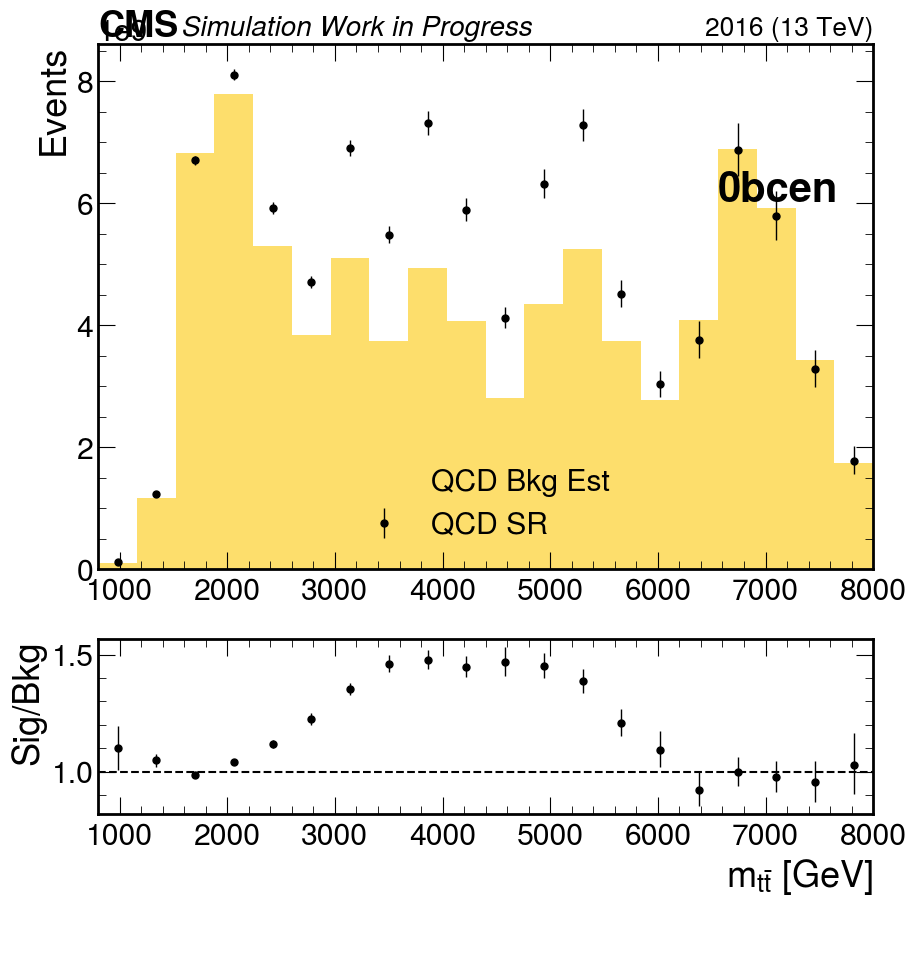

/opt/conda/lib/python3.8/site-packages/hist/basehist.py:324: UserWarning: List indexing selection is experimental. Removed bins are not placed in overflow.
  return super().__getitem__(self._index_transform(index))
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


images/png/closureTestQCD/2016all/closureTest_0bfwd_LINEAR_wideBins.png


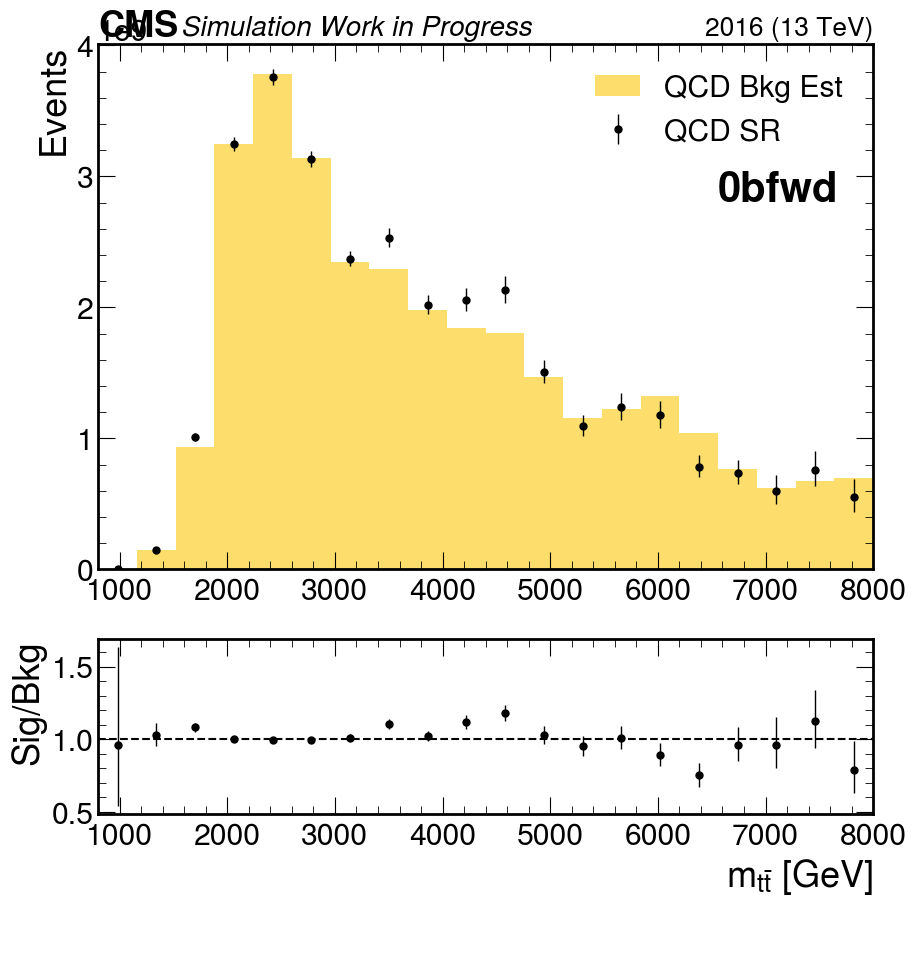

/opt/conda/lib/python3.8/site-packages/hist/basehist.py:324: UserWarning: List indexing selection is experimental. Removed bins are not placed in overflow.
  return super().__getitem__(self._index_transform(index))
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


images/png/closureTestQCD/2016all/closureTest_1bcen_LINEAR_wideBins.png


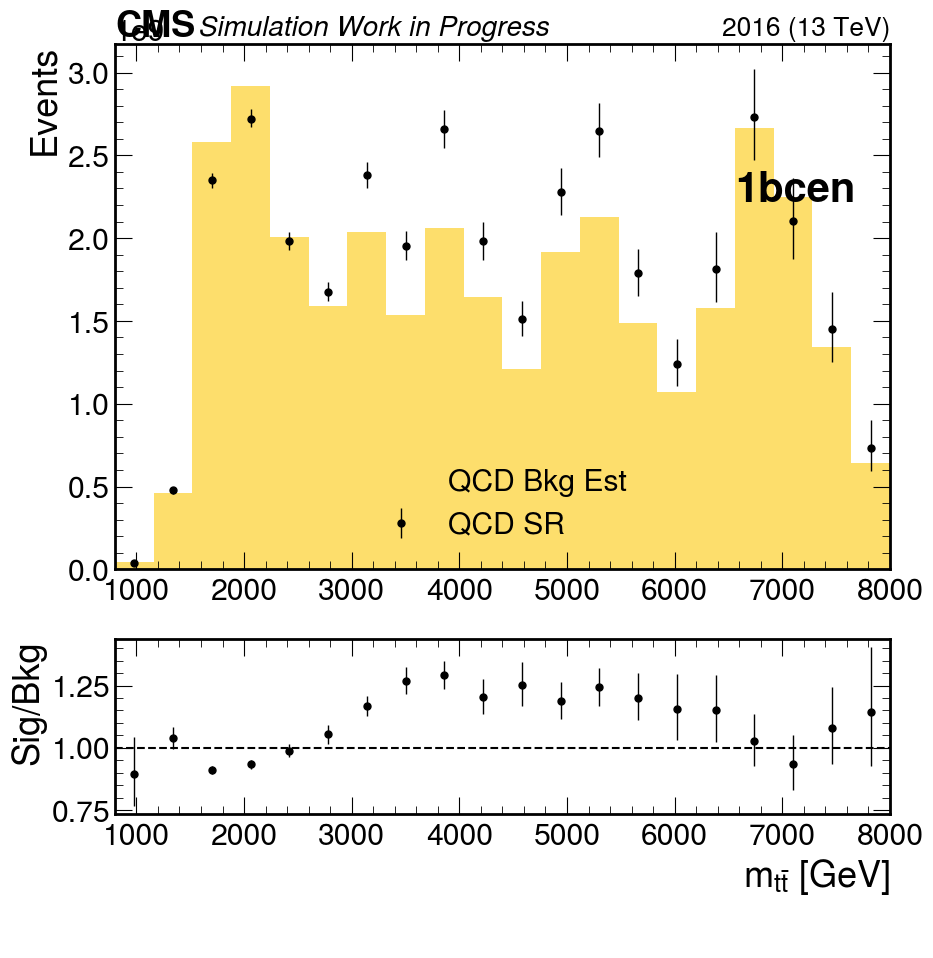

/opt/conda/lib/python3.8/site-packages/hist/basehist.py:324: UserWarning: List indexing selection is experimental. Removed bins are not placed in overflow.
  return super().__getitem__(self._index_transform(index))
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


images/png/closureTestQCD/2016all/closureTest_1bfwd_LINEAR_wideBins.png


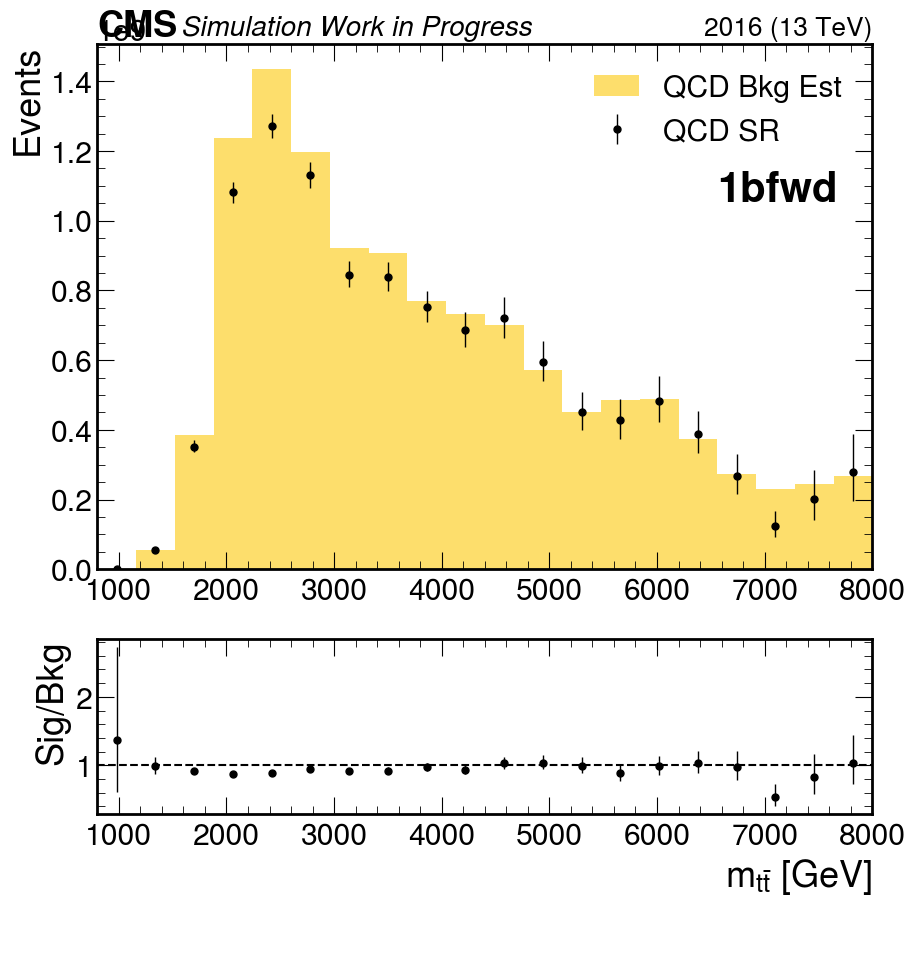

/opt/conda/lib/python3.8/site-packages/hist/basehist.py:324: UserWarning: List indexing selection is experimental. Removed bins are not placed in overflow.
  return super().__getitem__(self._index_transform(index))
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


images/png/closureTestQCD/2016all/closureTest_2bcen_LINEAR_wideBins.png


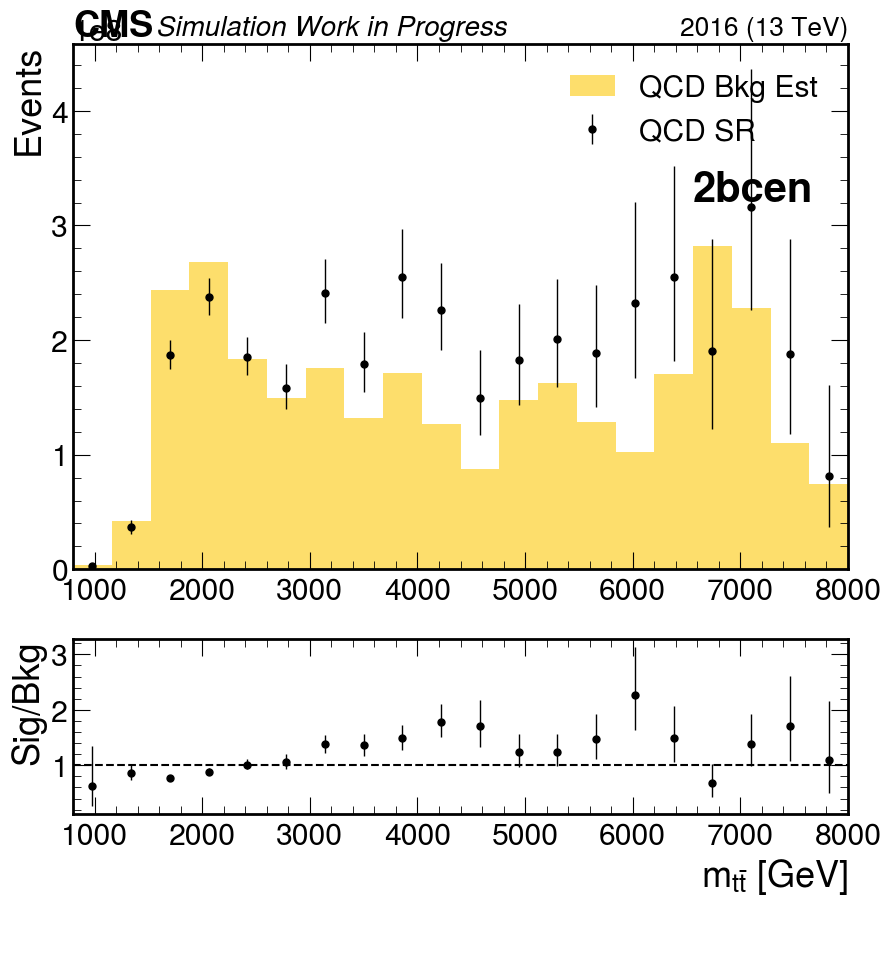

/opt/conda/lib/python3.8/site-packages/hist/basehist.py:324: UserWarning: List indexing selection is experimental. Removed bins are not placed in overflow.
  return super().__getitem__(self._index_transform(index))
/tmp/ipykernel_10634/1298834885.py:118: RuntimeWarning: divide by zero encountered in divide
  errs = ratio_plot.values() * np.sqrt( 1./(hbkg.values()*ratio_plot.values()) + (Errs**2/hbkg.values()**2) )
/tmp/ipykernel_10634/1298834885.py:118: RuntimeWarning: invalid value encountered in multiply
  errs = ratio_plot.values() * np.sqrt( 1./(hbkg.values()*ratio_plot.values()) + (Errs**2/hbkg.values()**2) )
/tmp/ipykernel_10634/1298834885.py:120: RuntimeWarning: divide by zero encountered in divide
  errs_stat = ratio_plot.values() * np.sqrt( 1./(hbkg.values()*ratio_plot.values()) + 1./(hbkg.values()) )
/tmp/ipykernel_10634/1298834885.py:120: RuntimeWarning: invalid value encountered in multiply
  errs_stat = ratio_plot.values() * np.sqrt( 1./(hbkg.values()*ratio_plot.values()) 

images/png/closureTestQCD/2016all/closureTest_2bfwd_LINEAR_wideBins.png


In [ ]:
if useCats:
    for cat in ['0bcen', '0bfwd', '1bcen', '1bfwd', '2bcen', '2bfwd']:

        fig, (ax1, ax2) = plt.subplots(nrows=2, height_ratios=[3, 1])

        Text = f'\tWork in Progress'
        # if Linear:
            # hep.cms.label('       '+Text, data=False, lumi='{0:0.1f}'.format(lumi[IOV]/1000.), year='2016', loc=2, fontsize=20, ax=ax1)
        hep.cms.label('       '+Text, data=False, year='2016', loc=0, fontsize=20, ax=ax1)
        # else:
        #     Text = f'\tWork in Progress'
        #     hep.cms.label('', data=False, lumi='{0:0.1f}'.format(lumi[IOV]/1000.), year='2016', loc=0, fontsize=20, ax=ax1)
        #     hep.cms.text(Text, loc=0, fontsize=20, ax=ax1)

        # qcdFiles = '15to7000 Flat\n1000to1400'
        plt.text(0.8, 0.7, cat, fontsize=30, fontweight='bold', transform=ax1.transAxes)
        # plt.text(0.6, 0.5, qcdFiles, fontsize=30, fontweight='bold', transform=ax1.transAxes)

        signal_cats = [label_to_int_dict['2t'+cat]] #[ i for label, i in label_to_int_dict.items() if '2t' in label]
        pretag_cats = [label_to_int_dict['pret'+cat]] #[ i for label, i in label_to_int_dict.items() if 'pret' in label]
        antitag_cats = [label_to_int_dict['at'+cat]] #[ i for label, i in label_to_int_dict.items() if 'pret' in label]

        if 'ttbarmass' in xaxis:
            hsig_apv = sig_apv['800to1000'][xaxis][{'anacat':signal_cats, 'systematic':'nominal'}][{'anacat':sum}] * sig_SF_apv['2016APV']['800to1000']
            hbkg_apv = bkg_apv['800to1000'][xaxis][{'anacat':pretag_cats, 'systematic':'nominal'}][{'anacat':sum}] * bkg_SF_apv['2016APV']['800to1000']
            hanti_apv = sig_apv['800to1000'][xaxis][{'anacat':antitag_cats, 'systematic':'nominal'}][{'anacat':sum}] * sig_SF_apv['2016APV']['800to1000']
            hpre_apv = sig_apv['800to1000'][xaxis][{'anacat':pretag_cats, 'systematic':'nominal'}][{'anacat':sum}] * sig_SF_apv['2016APV']['800to1000']
            hsig_noapv = sig_noapv['800to1000'][xaxis][{'anacat':signal_cats, 'systematic':'nominal'}][{'anacat':sum}] * sig_SF_noapv['2016']['800to1000']
            hbkg_noapv = bkg_noapv['800to1000'][xaxis][{'anacat':pretag_cats, 'systematic':'nominal'}][{'anacat':sum}] * bkg_SF_noapv['2016']['800to1000']
            hanti_noapv = sig_noapv['800to1000'][xaxis][{'anacat':antitag_cats, 'systematic':'nominal'}][{'anacat':sum}] * sig_SF_noapv['2016']['800to1000']
            hpre_noapv = sig_noapv['800to1000'][xaxis][{'anacat':pretag_cats, 'systematic':'nominal'}][{'anacat':sum}] * sig_SF_noapv['2016']['800to1000']
            
            # hsig_apv    = hsig_apv / np.sum(hsig_apv.values())
            # hbkg_apv    = hbkg_apv / np.sum(hbkg_apv.values())
            # hanti_apv   = hanti_apv / np.sum(hanti_apv.values())
            # hpre_apv    = hpre_apv / np.sum(hpre_apv.values())
            # hsig_noapv  = hsig_noapv / np.sum(hsig_noapv.values())
            # hbkg_noapv  = hbkg_noapv / np.sum(hbkg_noapv.values())
            # hanti_noapv = hanti_noapv / np.sum(hanti_noapv.values())
            # hpre_noapv  = hpre_noapv / np.sum(hpre_noapv.values())
            
            
            for pt in ['1000to1400', '1400to1800', '1800to2400', '2400to3200', '3200toInf']:
                hsig_apv_new = sig_apv[pt][xaxis][{'anacat':signal_cats, 'systematic':'nominal'}][{'anacat':sum}] * sig_SF_apv['2016APV'][pt]
                hbkg_apv_new = bkg_apv[pt][xaxis][{'anacat':pretag_cats, 'systematic':'nominal'}][{'anacat':sum}] * bkg_SF_apv['2016APV'][pt]
                hanti_apv_new = sig_apv[pt][xaxis][{'anacat':antitag_cats, 'systematic':'nominal'}][{'anacat':sum}] * sig_SF_apv['2016APV'][pt]
                hpre_apv_new = sig_apv[pt][xaxis][{'anacat':pretag_cats, 'systematic':'nominal'}][{'anacat':sum}] * sig_SF_apv['2016APV'][pt]
                hsig_noapv_new = sig_noapv[pt][xaxis][{'anacat':signal_cats, 'systematic':'nominal'}][{'anacat':sum}] * sig_SF_noapv['2016'][pt]
                hbkg_noapv_new = bkg_noapv[pt][xaxis][{'anacat':pretag_cats, 'systematic':'nominal'}][{'anacat':sum}] * bkg_SF_noapv['2016'][pt]
                hanti_noapv_new = sig_noapv[pt][xaxis][{'anacat':antitag_cats, 'systematic':'nominal'}][{'anacat':sum}] * sig_SF_noapv['2016'][pt]
                hpre_noapv_new = sig_noapv[pt][xaxis][{'anacat':pretag_cats, 'systematic':'nominal'}][{'anacat':sum}] * sig_SF_noapv['2016'][pt]
                
                hsig_apv    += hsig_apv_new #/ np.sum(hsig_apv_new.values())
                hbkg_apv    += hbkg_apv_new #/ np.sum(hbkg_apv_new.values())
                hanti_apv   += hanti_apv_new# / np.sum(hanti_apv_new.values())
                hpre_apv    += hpre_apv_new #/ np.sum(hpre_apv_new.values())
                hsig_noapv  += hsig_noapv_new #/ np.sum(hsig_noapv_new.values())
                hbkg_noapv  += hbkg_noapv_new #/ np.sum(hbkg_noapv_new.values())
                hanti_noapv += hanti_noapv_new# / np.sum(hanti_noapv_new.values())
                hpre_noapv  += hpre_noapv_new #/ np.sum(hpre_noapv_new.values())
                
                

        else:
            hsig_apv = sig_apv['800to1000'][xaxis][{'anacat':signal_cats}][{'anacat':sum}] * sig_SF_apv['2016APV']['800to1000']
            hbkg_apv = bkg_apv['800to1000'][xaxis][{'anacat':pretag_cats}][{'anacat':sum}] * bkg_SF_apv['2016APV']['800to1000']
            hanti_apv = sig_apv['800to1000'][xaxis][{'anacat':antitag_cats}][{'anacat':sum}] * sig_SF_apv['2016APV']['800to1000']
            hpre_apv = sig_apv['800to1000'][xaxis][{'anacat':pretag_cats}][{'anacat':sum}] * sig_SF_apv['2016APV']['800to1000']
            hsig_noapv = sig_noapv['800to1000'][xaxis][{'anacat':signal_cats}][{'anacat':sum}] * sig_SF_noapv['2016']['800to1000']
            hbkg_noapv = bkg_noapv['800to1000'][xaxis][{'anacat':pretag_cats}][{'anacat':sum}] * bkg_SF_noapv['2016']['800to1000']
            hanti_noapv = sig_noapv['800to1000'][xaxis][{'anacat':antitag_cats}][{'anacat':sum}] * sig_SF_noapv['2016']['800to1000']
            hpre_noapv = sig_noapv['800to1000'][xaxis][{'anacat':pretag_cats}][{'anacat':sum}] * sig_SF_noapv['2016']['800to1000']
            for pt in ['1000to1400', '1400to1800', '1800to2400', '2400to3200', '3200toInf']:
                hsig_apv += sig_apv[pt][xaxis][{'anacat':signal_cats}][{'anacat':sum}] * sig_SF_apv['2016APV'][pt]
                hbkg_apv += bkg_apv[pt][xaxis][{'anacat':pretag_cats}][{'anacat':sum}] * bkg_SF_apv['2016APV'][pt]
                hanti_apv += sig_apv[pt][xaxis][{'anacat':antitag_cats}][{'anacat':sum}] * sig_SF_apv['2016APV'][pt]
                hpre_apv += sig_apv[pt][xaxis][{'anacat':pretag_cats}][{'anacat':sum}] * sig_SF_apv['2016APV'][pt]
                hsig_noapv += sig_noapv[pt][xaxis][{'anacat':signal_cats}][{'anacat':sum}] * sig_SF_noapv['2016'][pt]
                hbkg_noapv += bkg_noapv[pt][xaxis][{'anacat':pretag_cats}][{'anacat':sum}] * bkg_SF_noapv['2016'][pt]
                hanti_noapv += sig_noapv[pt][xaxis][{'anacat':antitag_cats}][{'anacat':sum}] * sig_SF_noapv['2016'][pt]
                hpre_noapv += sig_noapv[pt][xaxis][{'anacat':pretag_cats}][{'anacat':sum}] * sig_SF_noapv['2016'][pt]

        hsig = hsig_noapv + hsig_apv
        hbkg = hbkg_noapv + hbkg_apv
        hanti = hanti_noapv + hanti_apv
        hpre = hpre_noapv + hpre_apv
        
        Ndenom = hanti.values()
        mistag = hbkg / hpre.values()
        term1 = np.ones(len(hpre.values()))/hpre.values()
        term2 = (np.ones(len(mistag.values()))-mistag.values())/(Ndenom*mistag.values())
        Errs = hbkg.values()*np.sqrt( term1 + term2 )
        Height = Errs * 2
        
        hsig = hsig #/ np.sum(hsig.values())
        hbkg = hbkg #/ np.sum(hbkg.values())
        hanti = hanti #/ np.sum(hanti.values())
        hpre = hpre #/ np.sum(hpre.values())
        
        Height = Height/np.sum(Height)
        Bottom = hbkg.values() - (Height/2.)
        
        
        hep.histplot(hsig, histtype='errorbar', ax=ax1, color='black', label='QCD SR')
        hep.histplot(hbkg, histtype='fill', ax=ax1, color='xkcd:pale gold', label='QCD Bkg Est')

        
        ax1.set_ylabel('Events')        
        ax1.set_yscale('log')
        # ax1.set_ylim(1e-4, 1e6)
        ax1.set_xlim(800,8000)
        ax2.set_xlim(800,8000)
            
        ax1.set_xlabel('')
        ax1.legend()
        
        ratio_plot =  (hsig) / (hbkg.values())
        errs = ratio_plot.values() * np.sqrt( 1./(hbkg.values()*ratio_plot.values()) + (Errs**2/hbkg.values()**2) ) 
        errs = errs / np.sum(errs)
        errs_stat = ratio_plot.values() * np.sqrt( 1./(hbkg.values()*ratio_plot.values()) + 1./(hbkg.values()) )
        errs_stat = 1./hbkg.values()
        
    
        if 'ttbarmass' in xaxis:
            Edges = hbkg.axes['ttbarmass'].edges
        elif 'jetp' in xaxis:
            Edges = hbkg.axes['jetp'].edges
        else:
            Edges = hbkg.axes[xaxis].edges
            
#         ax1.bar(x = Edges[:-1],
#                height=Height,
#                bottom=Bottom,
#                width = np.diff(Edges), align='edge', hatch='///', edgecolor='gray',
#                linewidth=0, facecolor='none', alpha=0.8,
#                zorder=10, label='Stat. Unc.')
        
        if Pull == False:

            # ax2.bar(x = Edges[:-1],
            #    height=(2.*errs),
            #    bottom=(np.ones_like(ratio_plot.values()) - errs),
            #    width = np.diff(Edges), align='edge', edgecolor='black',
            #    linewidth=0, facecolor='red', alpha=0.3,
            #    zorder=10, label='Tot. Unc.')

            # ax2.bar(x = Edges[:-1],
            #        height=(2.*errs_stat),
            #        bottom=(np.ones_like(ratio_plot.values()) - errs_stat),
            #        width = np.diff(Edges), align='edge', hatch='\\\\', edgecolor='black',
            #        linewidth=0, facecolor='blue', alpha=0.3,
            #        zorder=10, label='Stat. Unc.')

            legend2 = plt.legend(bbox_to_anchor =(0.1,-0.85), loc='lower center')
            hep.histplot(ratio_plot, ax=ax2, histtype='errorbar', color='black')
            # ax2.set_ylim(0,2)
            ax2.axhline(1, color='black', ls='--')
            ax2.set_ylabel('Sig/Bkg')
            
        else:
            
            DminusB = (hsig + -1*hbkg)
            pull_plot = DminusB / np.sqrt( hsig.values() + Height**2 ) 
            pull_plot_arr = np.where(hsig.values()>0., pull_plot.values(), np.nan)
            plot.plot_pull_array(pull_plot, pull_plot_arr, ax=ax2, bar_kwargs={'color':'steelblue'}, pp_kwargs={'alpha':0.5})

            ax2.set_ylim(-5.05,5.05)
            ax2.set_yticks([-4,-2,0,2,4])
            ax2.axhline(0, color='black', ls='--')
            ax2.set_ylabel(r'(S-B)/$\sigma$')
            
            pullstr = '_withPull'
            
        if hsig.values().max() > 1. and '2b' not in cat:
            maxylim = round(hsig.values().max()*2, -2)
        else:
            maxylim = 60.
        if Linear:
            ax1.set_yscale('linear')
            # ax1.set_ylim(0, 0.20)
            ax1.set_xlim(800,8000)
            ax2.set_xlim(800,8000)
            linearStr = '_LINEAR'
        
        savefilename = f'images/png/closureTestQCD/{IOV}/closureTest_{cat}{linearStr}{binstr}{pullstr}{oldHTstr}.png'
        print(savefilename)
#         plt.savefig(savefilename)
#         plt.savefig(savefilename.replace('png', 'pdf'))
        plt.show()
else:
    fig, (ax1, ax2) = plt.subplots(nrows=2, height_ratios=[3, 1])

    Text = f'simulation\nWork in Progress'
    if Linear:
        hep.cms.label('       '+Text, data=True, lumi='{0:0.1f}'.format(lumi[IOV]/1000.), year='2016', loc=2, fontsize=20, ax=ax1)
    else:
        Text = f'simulation\tWork in Progress'
        hep.cms.label('', data=True, lumi='{0:0.1f}'.format(lumi[IOV]/1000.), year='2016', loc=0, fontsize=20, ax=ax1)
        hep.cms.text(Text, loc=0, fontsize=20, ax=ax1)

    plt.text(0.7, 0.7, 'Inclusive', fontsize=30, fontweight='bold', transform=ax1.transAxes)

    signal_cats = [ i for label, i in label_to_int_dict.items() if '2t' in label]
    pretag_cats = [ i for label, i in label_to_int_dict.items() if 'pret' in label]
    antitag_cats = [ i for label, i in label_to_int_dict.items() if 'at' in label]

    if 'ttbarmass' in xaxis:
        hsig_apv = sig_apv[xaxis][{'anacat':signal_cats, 'systematic':'nominal'}][{'anacat':sum}] * qcdsf['2016APV']['sig']
        hbkg_apv = bkg_apv[xaxis][{'anacat':pretag_cats, 'systematic':'nominal'}][{'anacat':sum}] * qcdsf['2016APV']['bkg']
        hanti_apv = sig_apv[xaxis][{'anacat':antitag_cats, 'systematic':'nominal'}][{'anacat':sum}] * qcdsf['2016APV']['sig']
        hpre_apv = sig_apv[xaxis][{'anacat':pretag_cats, 'systematic':'nominal'}][{'anacat':sum}] * qcdsf['2016APV']['sig']
        hsig_noapv = sig_noapv[xaxis][{'anacat':signal_cats, 'systematic':'nominal'}][{'anacat':sum}] * qcdsf['2016']['sig']
        hbkg_noapv = bkg_noapv[xaxis][{'anacat':pretag_cats, 'systematic':'nominal'}][{'anacat':sum}] * qcdsf['2016']['bkg']
        hanti_noapv = sig_noapv[xaxis][{'anacat':antitag_cats, 'systematic':'nominal'}][{'anacat':sum}] * qcdsf['2016']['sig']
        hpre_noapv = sig_noapv[xaxis][{'anacat':pretag_cats, 'systematic':'nominal'}][{'anacat':sum}] * qcdsf['2016']['sig']

    else:
        hsig_apv = sig_apv[xaxis][{'anacat':signal_cats}][{'anacat':sum}] * qcdsf['2016APV']['sig']
        hbkg_apv = bkg_apv[xaxis][{'anacat':pretag_cats}][{'anacat':sum}] * qcdsf['2016APV']['bkg']
        hanti_apv = sig_apv[xaxis][{'anacat':antitag_cats}][{'anacat':sum}] * qcdsf['2016APV']['sig']
        hpre_apv = sig_apv[xaxis][{'anacat':pretag_cats}][{'anacat':sum}] * qcdsf['2016APV']['sig']
        hsig_noapv = sig_noapv[xaxis][{'anacat':signal_cats}][{'anacat':sum}] * qcdsf['2016']['sig']
        hbkg_noapv = bkg_noapv[xaxis][{'anacat':pretag_cats}][{'anacat':sum}] * qcdsf['2016']['bkg']
        hanti_noapv = sig_noapv[xaxis][{'anacat':antitag_cats}][{'anacat':sum}] * qcdsf['2016']['sig']
        hpre_noapv = sig_noapv[xaxis][{'anacat':pretag_cats}][{'anacat':sum}] * qcdsf['2016']['sig']


    hsig = hsig_apv + hsig_noapv
    hbkg = hbkg_apv + hbkg_noapv
    hanti = hanti_apv + hanti_noapv
    hpre = hpre_apv + hpre_noapv

    hep.histplot(hsig, histtype='errorbar', ax=ax1, color='black', label='QCD SR')
    hep.histplot(hbkg, histtype='fill', ax=ax1, color='xkcd:pale gold', label='QCD Bkg Est')
    
    Ndenom = hanti.values()
    mistag = hbkg / hpre.values()
    term1 = np.ones(len(hpre.values()))/hpre.values()
    term2 = (np.ones(len(mistag.values()))-mistag.values())/(Ndenom*mistag.values())
    Errs = hbkg.values()*np.sqrt( term1 + term2 )
    Height = Errs * 2
    Bottom = hbkg.values() - Errs

    ax1.legend()
    ax1.set_ylabel('Events')
    ax1.set_yscale('log')
    ax1.set_ylim(0., 0.05)
    # if not Linear:
    #     ax1.set_ylim(1e-4, 1e4)
    #     ax1.set_xlim(900,8000)
    #     ax2.set_xlim(900,8000)
    ax1.set_xlabel('')

    ratio_plot =  hsig / hbkg.values()
    errs = ratio_plot.values() * np.sqrt( (1./hbkg.values()*ratio_plot.values()) + (Errs**2/hbkg.values()**2) ) 
    errs_stat = ratio_plot.values() * np.sqrt( 1./(hbkg.values()*ratio_plot.values()) + 1./(hbkg.values()) )
    errs_stat = 1./hbkg.values()
    
    
    if 'ttbarmass' in xaxis:
        Edges = hbkg.axes['ttbarmass'].edges
    elif 'jetp' in xaxis:
        Edges = hbkg.axes['jetp'].edges
    else:
        Edges = hbkg.axes[xaxis].edges
        
    # ax1.bar(x = Edges[:-1],
    #            height=Height,
    #            bottom=Bottom,
    #            width = np.diff(Edges), align='edge', hatch='///', edgecolor='gray',
    #            linewidth=0, facecolor='none', alpha=0.8,
    #            zorder=10, label='Bkg. Est. Unc.')
    
    if Pull == False:

        ax2.bar(x = Edges[:-1],
               height=(2.*errs),
               bottom=(np.ones_like(ratio_plot.values()) - errs),
               width = np.diff(Edges), align='edge', edgecolor='black',
               linewidth=0, facecolor='red', alpha=0.3,
               zorder=10, label='Tot. Unc.')

        ax2.bar(x = Edges[:-1],
               height=(2.*errs_stat),
               bottom=(np.ones_like(ratio_plot.values()) - errs_stat),
               width = np.diff(Edges), align='edge', hatch='\\\\', edgecolor='black',
               linewidth=0, facecolor='blue', alpha=0.3,
               zorder=10, label='Stat. Unc.')
        
        legend2 = plt.legend(bbox_to_anchor =(0.1,-0.85), loc='lower center')
        hep.histplot(ratio_plot, ax=ax2, histtype='errorbar', color='black')
        ax2.set_ylim(0,2)
        ax2.axhline(1, color='black', ls='--')
        ax2.set_ylabel('Sig/Bkg')
    
    elif Pull == True:
        
        DminusB = (hsig + -1*hbkg)
        pull_plot = DminusB / np.sqrt( hsig.values() + Errs**2 ) 
        pull_plot_arr = np.where(hsig.values()>0., pull_plot.values(), np.nan)
        plot.plot_pull_array(pull_plot, pull_plot_arr, ax=ax2, bar_kwargs={'color':'steelblue'}, pp_kwargs={'alpha':0.5})
                     
        ax2.set_ylim(-5.05,5.05)
        ax2.set_yticks([-4,-2,0,2,4])
        ax2.axhline(0, color='black', ls='--')
        ax2.set_ylabel(r'(S-B)/$\sigma$')
        
        pullstr = '_withPull'
    
    if hsig.values().max() > 1.:
        maxylim = round(hsig.values().max()*2, -2)
    
    # if Linear:
    #     ax1.set_yscale('linear')
    #     # ax1.set_ylim(0, maxylim)
    #     ax1.set_xlim(900,4000)
    #     ax2.set_xlim(900,4000)
    #     linearStr = '_LINEAR'
    
    savefilename = f'images/png/closureTestQCD/{IOV}/closureTest_inclusive{linearStr}{binstr}{pullstr}{oldHTstr}.png'
    print(savefilename)
#     plt.savefig(savefilename)
#     plt.savefig(savefilename.replace('png', 'pdf'))
    plt.show()

# QCD Closure of Full Luminosity:

In [10]:
# IOV = 'Full'
# xaxis = 'ttbarmass_fine'
# Linear = False
# linearStr = ''
# binstr = ''
# useCats = False

# sig = {
#     '2016APV': util.load(coffeaFiles['unweighted']['2016APV']),
#     '2016': util.load(coffeaFiles['unweighted']['2016']),
#     '2017': util.load(coffeaFiles['unweighted']['2017']),
#     '2018': util.load(coffeaFiles['unweighted']['2018'])
# }
# bkg = {
#     '2016APV': util.load(coffeaFiles['weighted']['2016APV']),
#     '2016': util.load(coffeaFiles['weighted']['2016']),
#     '2017': util.load(coffeaFiles['weighted']['2017']),
#     '2018': util.load(coffeaFiles['weighted']['2018'])
# }


# qcdsf = {
#     '2016APV':{
#         'sig': lumi['2016APV'] * qcd_xs / (sig['2016APV']['cutflow']['sumw all']),
#         'bkg': lumi['2016APV'] * qcd_xs / (bkg['2016APV']['cutflow']['sumw all'])
#     },
#     '2016':{
#         'sig': lumi['2016'] * qcd_xs / (sig['2016']['cutflow']['sumw all']),
#         'bkg': lumi['2016'] * qcd_xs / (bkg['2016']['cutflow']['sumw all'])
#     },
#     '2017':{
#         'sig': lumi['2017'] * qcd_xs / (sig['2017']['cutflow']['sumw all']),
#         'bkg': lumi['2017'] * qcd_xs / (bkg['2017']['cutflow']['sumw all'])
#     },
#     '2018':{
#         'sig': lumi['2018'] * qcd_xs / (sig['2018']['cutflow']['sumw all']),
#         'bkg': lumi['2018'] * qcd_xs / (bkg['2018']['cutflow']['sumw all'])
#     }
# }

# if 'fine' not in xaxis:
#     binstr = '_wideBins'

# if useCats:
#     for cat in ['0bcen', '0bfwd', '1bcen', '1bfwd', '2bcen', '2bfwd']:

#         fig, (ax1, ax2) = plt.subplots(nrows=2, height_ratios=[3, 1])
        

#         Text = f'simulation\nWork in Progress'
#         if IOV == 'Full':
#             if Linear:
#                 hep.cms.label('       '+Text, data=True, lumi='{0:0.1f}'.format(lumi[IOV]/1000.), loc=2, fontsize=20, ax=ax1)
#             else:
#                 Text = f'simulation\tWork in Progress'
#                 hep.cms.label('', data=True, lumi='{0:0.1f}'.format(lumi[IOV]/1000.), loc=0, fontsize=20, ax=ax1)
#                 hep.cms.text(Text, loc=0, fontsize=20, ax=ax1)
#         else:
#             if Linear:
#                 hep.cms.label('       '+Text, data=True, lumi='{0:0.1f}'.format(lumi[IOV]/1000.), year=IOV, loc=2, fontsize=20, ax=ax1)
#             else:
#                 Text = f'simulation\tWork in Progress'
#                 hep.cms.label('', data=True, lumi='{0:0.1f}'.format(lumi[IOV]/1000.), year=IOV, loc=0, fontsize=20, ax=ax1)
#                 hep.cms.text(Text, loc=0, fontsize=20, ax=ax1)

#         plt.text(0.8, 0.7, cat, fontsize=30, fontweight='bold', transform=ax1.transAxes)

#         signal_cats = [label_to_int_dict['2t'+cat]] #[ i for label, i in label_to_int_dict.items() if '2t' in label]
#         pretag_cats = [label_to_int_dict['pret'+cat]] #[ i for label, i in label_to_int_dict.items() if 'pret' in label]
#         antitag_cats = [label_to_int_dict['at'+cat]] #[ i for label, i in label_to_int_dict.items() if 'pret' in label]

#         hsig_apv = sig['2016APV'][xaxis][{'anacat':signal_cats, 'systematic':'nominal'}][{'anacat':sum}] * qcdsf['2016APV']['sig']
#         hbkg_apv = bkg['2016APV'][xaxis][{'anacat':pretag_cats, 'systematic':'nominal'}][{'anacat':sum}] * qcdsf['2016APV']['bkg']
#         hanti_apv = sig['2016APV'][xaxis][{'anacat':antitag_cats, 'systematic':'nominal'}][{'anacat':sum}] * qcdsf['2016APV']['sig']
#         hpre_apv = sig['2016APV'][xaxis][{'anacat':pretag_cats, 'systematic':'nominal'}][{'anacat':sum}] * qcdsf['2016APV']['sig']
#         hsig_noapv = sig['2016'][xaxis][{'anacat':signal_cats, 'systematic':'nominal'}][{'anacat':sum}] * qcdsf['2016']['sig']
#         hbkg_noapv = bkg['2016'][xaxis][{'anacat':pretag_cats, 'systematic':'nominal'}][{'anacat':sum}] * qcdsf['2016']['bkg']
#         hanti_noapv = sig['2016'][xaxis][{'anacat':antitag_cats, 'systematic':'nominal'}][{'anacat':sum}] * qcdsf['2016']['sig']
#         hpre_noapv = sig['2016'][xaxis][{'anacat':pretag_cats, 'systematic':'nominal'}][{'anacat':sum}] * qcdsf['2016']['sig']
#         hsig_17 = sig['2017'][xaxis][{'anacat':signal_cats, 'systematic':'nominal'}][{'anacat':sum}] * qcdsf['2017']['sig']
#         hbkg_17 = bkg['2017'][xaxis][{'anacat':pretag_cats, 'systematic':'nominal'}][{'anacat':sum}] * qcdsf['2017']['bkg']
#         hanti_17 = sig['2017'][xaxis][{'anacat':antitag_cats, 'systematic':'nominal'}][{'anacat':sum}] * qcdsf['2017']['sig']
#         hpre_17 = sig['2017'][xaxis][{'anacat':pretag_cats, 'systematic':'nominal'}][{'anacat':sum}] * qcdsf['2017']['sig']
#         hsig_18 = sig['2018'][xaxis][{'anacat':signal_cats, 'systematic':'nominal'}][{'anacat':sum}] * qcdsf['2018']['sig']
#         hbkg_18 = bkg['2018'][xaxis][{'anacat':pretag_cats, 'systematic':'nominal'}][{'anacat':sum}] * qcdsf['2018']['bkg']
#         hanti_18 = sig['2018'][xaxis][{'anacat':antitag_cats, 'systematic':'nominal'}][{'anacat':sum}] * qcdsf['2018']['sig']
#         hpre_18 = sig['2018'][xaxis][{'anacat':pretag_cats, 'systematic':'nominal'}][{'anacat':sum}] * qcdsf['2018']['sig']
        
        
#         if IOV == '2017':
#             hsig = hsig_17
#             hbkg = hbkg_17
#             hanti = hanti_17
#             hpre = hpre_17 
#         elif IOV == '2018':
#             hsig = hsig_18
#             hbkg = hbkg_18
#             hanti = hanti_18
#             hpre = hpre_18 
#         elif IOV == 'Full':
#             hsig = hsig_apv + hsig_noapv + hsig_17 + hsig_18
#             hbkg = hbkg_apv + hbkg_noapv + hbkg_17 + hbkg_18
#             hanti = hanti_apv + hanti_noapv + hanti_17 + hanti_18
#             hpre = hpre_apv + hpre_noapv + hpre_17 + hpre_18
#         else:
#             break
        
#         hep.histplot(hsig, histtype='errorbar', ax=ax1, color='black', label='QCD SR')
#         hep.histplot(hbkg, histtype='fill', ax=ax1, color='xkcd:pale gold', label='QCD Bkg Est')
        
#         Ndenom = hanti.values()
#         mistag = hbkg / hpre.values()
#         term1 = np.ones(len(hpre.values()))/hpre.values()
#         term2 = (np.ones(len(mistag.values()))-mistag.values())/(Ndenom*mistag.values())
#         Errs = hbkg.values()*np.sqrt( term1 + term2 )
#         Height = Errs * 2
#         Bottom = hbkg.values() - Errs
#         Edges = hbkg.axes['ttbarmass'].edges

#         ax1.legend()
#         ax1.set_ylabel('Events')
#         ax1.set_yscale('log')
#         if not Linear:
#             ax1.set_ylim(1e-1, 1e4)
#             ax1.set_xlim(900,8000)
#             ax2.set_xlim(900,8000)
#         ax1.set_xlabel('')

#         ratio_plot =  hsig / hbkg.values()
#         errs = np.sqrt( (hsig.values()/hbkg.values()**2) + (Errs/hbkg.values()**2)**2 ) 
#         errs_stat = 1./hbkg.values()
#         if 'ttbarmass' in xaxis:
#             edges = hbkg.axes['ttbarmass'].edges
#         else:
#             edges = hbkg.axes[xaxis].edges
            
#         ax1.bar(x = Edges[:-1],
#            height=Height,
#            bottom=Bottom,
#            width = np.diff(Edges), align='edge', hatch='///', edgecolor='gray',
#            linewidth=0, facecolor='none', alpha=0.8,
#            zorder=10, label='Stat. Unc.')

#         ax2.bar(x = edges[:-1],
#            height=(2.*errs),
#            bottom=(np.ones_like(ratio_plot.values()) - errs),
#            width = np.diff(edges), align='edge', edgecolor='black',
#            linewidth=0, facecolor='red', alpha=0.3,
#            zorder=10, label='Unc.')
    
#         ax2.bar(x = edges[:-1],
#                height=(2.*errs_stat),
#                bottom=(np.ones_like(ratio_plot.values()) - errs_stat),
#                width = np.diff(edges), align='edge', hatch='\\\\', edgecolor='black',
#                linewidth=0, facecolor='blue', alpha=0.3,
#                zorder=10, label='Obs. Stat. Unc.')

#         legend2 = plt.legend(bbox_to_anchor =(0.1,-0.85), loc='lower center')

#         hep.histplot(ratio_plot, ax=ax2, histtype='errorbar', color='black')
#         ax2.set_ylim(0,2)
#         ax2.axhline(1, color='black', ls='--')
#         ax2.set_ylabel('Sig/Bkg')
        
#         if hsig.values().max() > 1. and '2b' not in cat:
#             maxylim = round(hsig.values().max()*2, -2)
#         else:
#             maxylim = 100.
#         if Linear:
#             ax1.set_yscale('linear')
#             ax1.set_ylim(0, maxylim)
#             ax1.set_xlim(900,4000)
#             ax2.set_xlim(900,4000)
#             linearStr = '_LINEAR'
        
# #         savefilename = f'images/png/closureTestQCD/{IOV}/closureTest_{cat}{linearStr}{binstr}.png'
# #         print(savefilename)
# #         plt.savefig(savefilename)
# #         plt.savefig(savefilename.replace('png', 'pdf'))
#         plt.show()
# else:

#     fig, (ax1, ax2) = plt.subplots(nrows=2, height_ratios=[3, 1])

#     Text = f'simulation\nWork in Progress'
#     if IOV == 'Full':
#         if Linear:
#             hep.cms.label('       '+Text, data=True, lumi='{0:0.1f}'.format(lumi[IOV]/1000.), loc=2, fontsize=20, ax=ax1)
#         else:
#             Text = f'simulation\tWork in Progress'
#             hep.cms.label('', data=True, lumi='{0:0.1f}'.format(lumi[IOV]/1000.), loc=0, fontsize=20, ax=ax1)
#             hep.cms.text(Text, loc=0, fontsize=20, ax=ax1)
#     else:
#         if Linear:
#             hep.cms.label('       '+Text, data=True, lumi='{0:0.1f}'.format(lumi[IOV]/1000.), year=IOV, loc=2, fontsize=20, ax=ax1)
#         else:
#             Text = f'simulation\tWork in Progress'
#             hep.cms.label('', data=True, lumi='{0:0.1f}'.format(lumi[IOV]/1000.), year=IOV, loc=0, fontsize=20, ax=ax1)
#             hep.cms.text(Text, loc=0, fontsize=20, ax=ax1)

#     plt.text(0.7, 0.7, 'Inclusive', fontsize=30, fontweight='bold', transform=ax1.transAxes)

#     signal_cats = [ i for label, i in label_to_int_dict.items() if '2t' in label]
#     pretag_cats = [ i for label, i in label_to_int_dict.items() if 'pret' in label]
#     antitag_cats = [ i for label, i in label_to_int_dict.items() if 'at' in label]

#     hsig_apv = sig['2016APV'][xaxis][{'anacat':signal_cats, 'systematic':'nominal'}][{'anacat':sum}] * qcdsf['2016APV']['sig']
#     hbkg_apv = bkg['2016APV'][xaxis][{'anacat':pretag_cats, 'systematic':'nominal'}][{'anacat':sum}] * qcdsf['2016APV']['bkg']
#     hanti_apv = sig['2016APV'][xaxis][{'anacat':antitag_cats, 'systematic':'nominal'}][{'anacat':sum}] * qcdsf['2016APV']['sig']
#     hpre_apv = sig['2016APV'][xaxis][{'anacat':pretag_cats, 'systematic':'nominal'}][{'anacat':sum}] * qcdsf['2016APV']['sig']
#     hsig_noapv = sig['2016'][xaxis][{'anacat':signal_cats, 'systematic':'nominal'}][{'anacat':sum}] * qcdsf['2016']['sig']
#     hbkg_noapv = bkg['2016'][xaxis][{'anacat':pretag_cats, 'systematic':'nominal'}][{'anacat':sum}] * qcdsf['2016']['bkg']
#     hanti_noapv = sig['2016'][xaxis][{'anacat':antitag_cats, 'systematic':'nominal'}][{'anacat':sum}] * qcdsf['2016']['sig']
#     hpre_noapv = sig['2016'][xaxis][{'anacat':pretag_cats, 'systematic':'nominal'}][{'anacat':sum}] * qcdsf['2016']['sig']
#     hsig_17 = sig['2017'][xaxis][{'anacat':signal_cats, 'systematic':'nominal'}][{'anacat':sum}] * qcdsf['2017']['sig']
#     hbkg_17 = bkg['2017'][xaxis][{'anacat':pretag_cats, 'systematic':'nominal'}][{'anacat':sum}] * qcdsf['2017']['bkg']
#     hanti_17 = sig['2017'][xaxis][{'anacat':antitag_cats, 'systematic':'nominal'}][{'anacat':sum}] * qcdsf['2017']['sig']
#     hpre_17 = sig['2017'][xaxis][{'anacat':pretag_cats, 'systematic':'nominal'}][{'anacat':sum}] * qcdsf['2017']['sig']
#     hsig_18 = sig['2018'][xaxis][{'anacat':signal_cats, 'systematic':'nominal'}][{'anacat':sum}] * qcdsf['2018']['sig']
#     hbkg_18 = bkg['2018'][xaxis][{'anacat':pretag_cats, 'systematic':'nominal'}][{'anacat':sum}] * qcdsf['2018']['bkg']
#     hanti_18 = sig['2018'][xaxis][{'anacat':antitag_cats, 'systematic':'nominal'}][{'anacat':sum}] * qcdsf['2018']['sig']
#     hpre_18 = sig['2018'][xaxis][{'anacat':pretag_cats, 'systematic':'nominal'}][{'anacat':sum}] * qcdsf['2018']['sig']

#     if IOV == '2017':
#         hsig = hsig_17
#         hbkg = hbkg_17
#         hanti = hanti_17
#         hpre = hpre_17 
#     elif IOV == '2018':
#         hsig = hsig_18
#         hbkg = hbkg_18
#         hanti = hanti_18
#         hpre = hpre_18 
#     elif IOV == 'Full':
#         hsig = hsig_apv + hsig_noapv + hsig_17 + hsig_18
#         hbkg = hbkg_apv + hbkg_noapv + hbkg_17 + hbkg_18
#         hanti = hanti_apv + hanti_noapv + hanti_17 + hanti_18
#         hpre = hpre_apv + hpre_noapv + hpre_17 + hpre_18
#     else:
#         quit()

#     hep.histplot(hsig, histtype='errorbar', ax=ax1, color='black', label='QCD SR')
#     hep.histplot(hbkg, histtype='fill', ax=ax1, color='xkcd:pale gold', label='QCD Bkg Est')
    
#     Ndenom = hanti.values()
#     mistag = hbkg / hpre.values()
#     term1 = np.ones(len(hpre.values()))/hpre.values()
#     term2 = (np.ones(len(mistag.values()))-mistag.values())/(Ndenom*mistag.values())
#     Errs = hbkg.values()*np.sqrt( term1 + term2 )
#     Height = Errs * 2
#     Bottom = hbkg.values() - Errs
#     Edges = hbkg.axes['ttbarmass'].edges

#     ax1.legend()
#     ax1.set_ylabel('Events')
#     ax1.set_yscale('log')
#     if not Linear:
#         ax1.set_ylim(1e-1, 1e4)
#         ax1.set_xlim(900,8000)
#         ax2.set_xlim(900,8000)
#     ax1.set_xlabel('')

#     ratio_plot =  hsig / hbkg.values()
#     errs = np.sqrt( (hsig.values()/hbkg.values()**2) + (Errs/hbkg.values()**2)**2 ) 
#     errs_stat = 1./hbkg.values()
#     if 'ttbarmass' in xaxis:
#         edges = hbkg.axes['ttbarmass'].edges
#     else:
#         edges = hbkg.axes[xaxis].edges
    
#     ax1.bar(x = Edges[:-1],
#            height=Height,
#            bottom=Bottom,
#            width = np.diff(Edges), align='edge', hatch='///', edgecolor='gray',
#            linewidth=0, facecolor='none', alpha=0.8,
#            zorder=10, label='Bkg. Est. Unc.')

#     ax2.bar(x = edges[:-1],
#            height=(2.*errs),
#            bottom=(np.ones_like(ratio_plot.values()) - errs),
#            width = np.diff(edges), align='edge', edgecolor='black',
#            linewidth=0, facecolor='red', alpha=0.3,
#            zorder=10, label='Unc.')
    
#     ax2.bar(x = edges[:-1],
#            height=(2.*errs_stat),
#            bottom=(np.ones_like(ratio_plot.values()) - errs_stat),
#            width = np.diff(edges), align='edge', hatch='\\\\', edgecolor='black',
#            linewidth=0, facecolor='blue', alpha=0.3,
#            zorder=10, label='Obs. Stat. Unc.')
    
#     legend2 = plt.legend(bbox_to_anchor =(0.1,-0.85), loc='lower center')
#     hep.histplot(ratio_plot, ax=ax2, histtype='errorbar', color='black')
#     ax2.set_ylim(0,2)
#     ax2.axhline(1, color='black', ls='--')
#     ax2.set_ylabel('Sig/Bkg')
    
#     if hsig.values().max() > 1.:
#         maxylim = round(hsig.values().max()*2, -2)
    
#     if Linear:
#         ax1.set_yscale('linear')
#         ax1.set_ylim(0, maxylim)
#         ax1.set_xlim(900,4000)
#         ax2.set_xlim(900,4000)
#         linearStr = '_LINEAR'
#     savefilename = f'images/png/closureTestQCD/{IOV}/closureTest_inclusive{linearStr}{binstr}.png'
#     print(savefilename)
#     plt.savefig(savefilename)                                                                                                                          
#     plt.savefig(savefilename.replace('png', 'pdf'))
#     plt.show()